# Структура на Jupyter Notebook: EDA II

## 1. Подготовка (Setup)
Зареждане на библиотеки и данни.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Configure plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data
DATA_PATH = '../data/raw/Bonn_EEG_Train.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/processed/Bonn_EEG_Train.csv'
    
df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset with {df.shape[0]} samples and {df.shape[1]} columns.")

label_cols = ['y_0', 'y_1', 'y_2']
class_map = {0: 'Healthy', 1: 'Inter-ictal', 2: 'Seizure'}

if all(c in df.columns for c in label_cols):
    df['Class_Num'] = df[label_cols].idxmax(axis=1).apply(lambda s: int(s.split('_')[1]))
    df['Class'] = df['Class_Num'].map(class_map)
else:
    print("Warning: One-hot encoded labels not found. Check dataset structure.")

Loaded dataset with 26312 samples and 189 columns.


## Точка 1: Анализ на връзката признак–цел (Feature-Target Analysis)
**Цел:** Да покажем кои характеристики най-добре различават Здрави от Болни.

### Графики: Box Plots (диаграми с кутийки)

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_14190/1711398923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='RMS', data=df, ax=axes[0], palette='viridis', order=['Healthy', 'Inter-ictal', 'Seizure'])
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_14190/1711398923.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Hjorth_Mobility', data=df, ax=axes[1], palette='viridis', order=['Healthy', 'Inter-ictal', 'Seizure'])


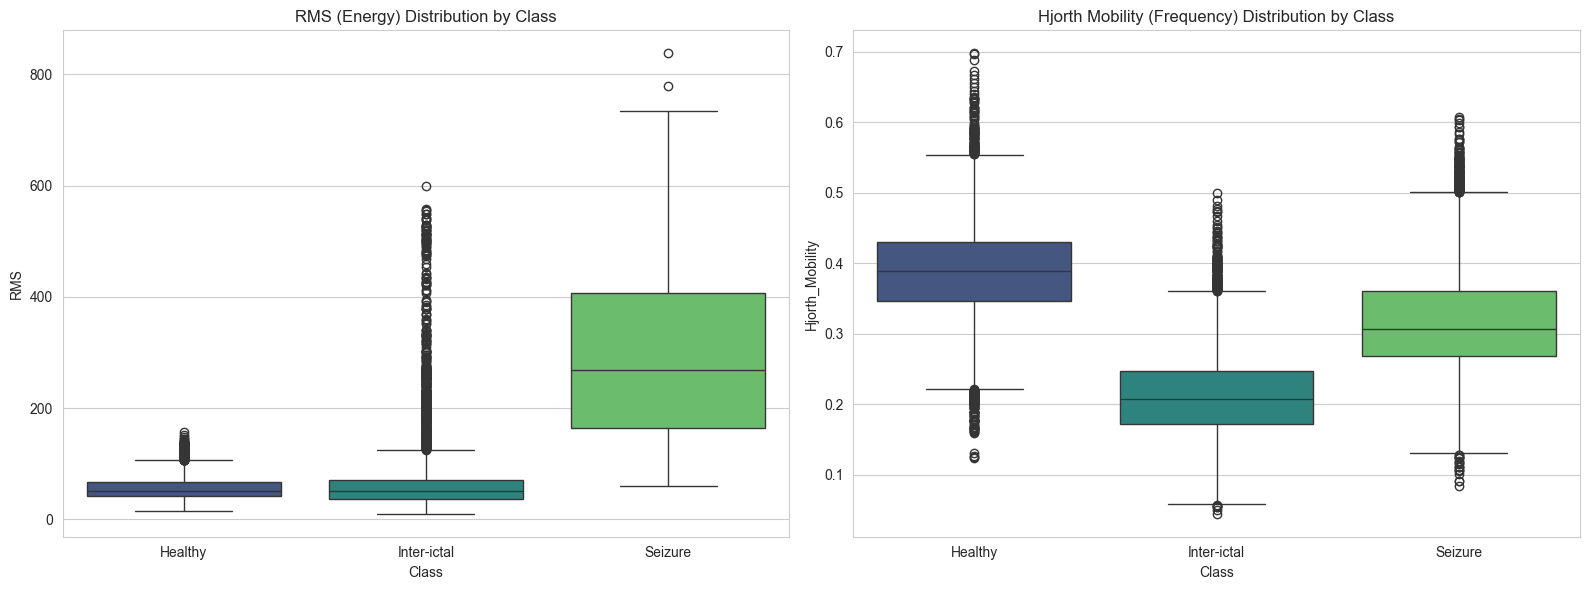

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box Plot for RMS
sns.boxplot(x='Class', y='RMS', data=df, ax=axes[0], palette='viridis', order=['Healthy', 'Inter-ictal', 'Seizure'])
axes[0].set_title('RMS (Energy) Distribution by Class')

# Box Plot for Hjorth_Mobility
sns.boxplot(x='Class', y='Hjorth_Mobility', data=df, ax=axes[1], palette='viridis', order=['Healthy', 'Inter-ictal', 'Seizure'])
axes[1].set_title('Hjorth Mobility (Frequency) Distribution by Class')

plt.tight_layout()
plt.show()

### Анализ:

"На графиката за RMS (енергия) се вижда ясно разграничение на клас Seizure (Пристъп) – стойностите са много по-високи и варират силно (висока дисперсия). Това отговаря на физиологичната хиперсинхронизация."

"На графиката за Hjorth Mobility (честота) се вижда, че Healthy (Здрави) имат по-висока средна честота, докато при Seizure и Inter-ictal тя спада. Това потвърждава спектралното изместване към ниските честоти."

**Извод:** И двете характеристики са силни дискриминатори, но работят по различен начин (едната по амплитуда, другата по честота).

## Точка 2: Анализ на вътрешни зависимости (Internal Correlations)
**Цел:** Да открием дали някои характеристики се повтарят (мултиколинеарност).

### Графика: Correlation Heatmap

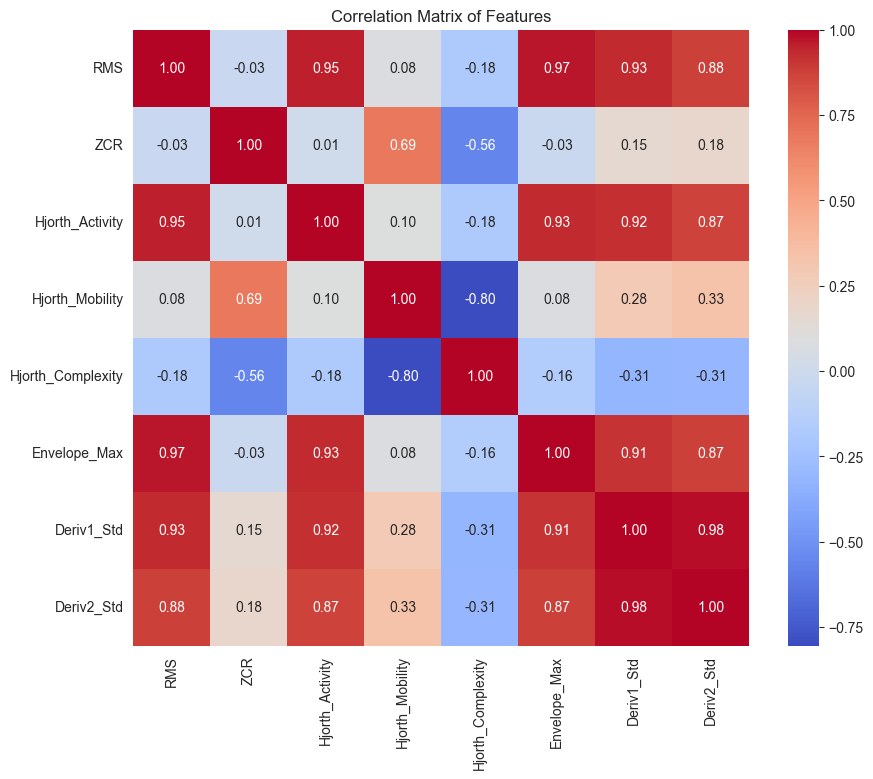

In [3]:
# Define list of feature columns
feature_cols = [
    'RMS', 'ZCR', 
    'Hjorth_Activity', 'Hjorth_Mobility', 'Hjorth_Complexity',
    'Envelope_Mean', 'Envelope_Max', 
    'Deriv1_Mean', 'Deriv1_Std', 
    'Deriv2_Mean', 'Deriv2_Std'
]
# Filter to those present
features_present = [f for f in feature_cols if f in df.columns]

plt.figure(figsize=(10, 8))
corr = df[features_present].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()

Матрицата показва няколко екстремни корелации:
1.	RMS <-> Envelope_Mean (0.997): Това е почти 100% съвпадение. Двете мерят средната сила на сигнала. 
2.	RMS <-> Envelope_Max (0.971): Пиковата амплитуда е свързана пряко със средната енергия.
3.	RMS <-> Hjorth_Activity (0.954): Hjorth Activity всъщност е вариацията. При сигнал със средна 0, вариацията е пропорционална на RMS на квадрат. 
4.	Deriv1_Std <-> Deriv2_Std (0.984): Вариацията на първата и втората производна са силно свързани – ако сигналът е "нервен", той е нервен и в двете.


## Точка 3: Анализ на разпределения (Distribution Analysis)
**Цел:** Да видим дали данните са "криви" и има ли екстремни стойности.

### Графика: Box Plots (Outliers focus)

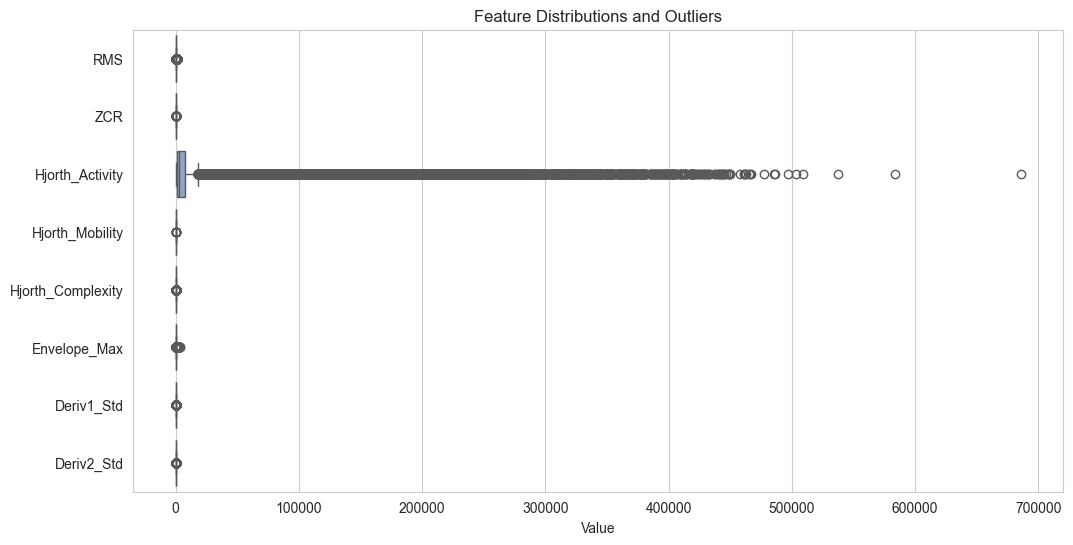

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features_present], orient='h', palette='Set2')
plt.title('Feature Distributions and Outliers')
plt.xlabel('Value')
plt.show()

### Анализ:

"Разпределенията не са нормални. При клас Seizure се наблюдават множество екстремни стойности (outliers) в посока на високите амплитуди."

"Класовият баланс е 2:2:1 (както установихме в Задание 1), което е приемливо, но при метриките за оценка на модела трябва да се вземе предвид по-малкият брой пристъпи."

## Точка 4: Намаляване на размерността (Dimensionality Reduction)
**Цел:** Да видим "голямата картина" – дали класовете се разделят визуално.

### Графика: PCA Scatter Plot

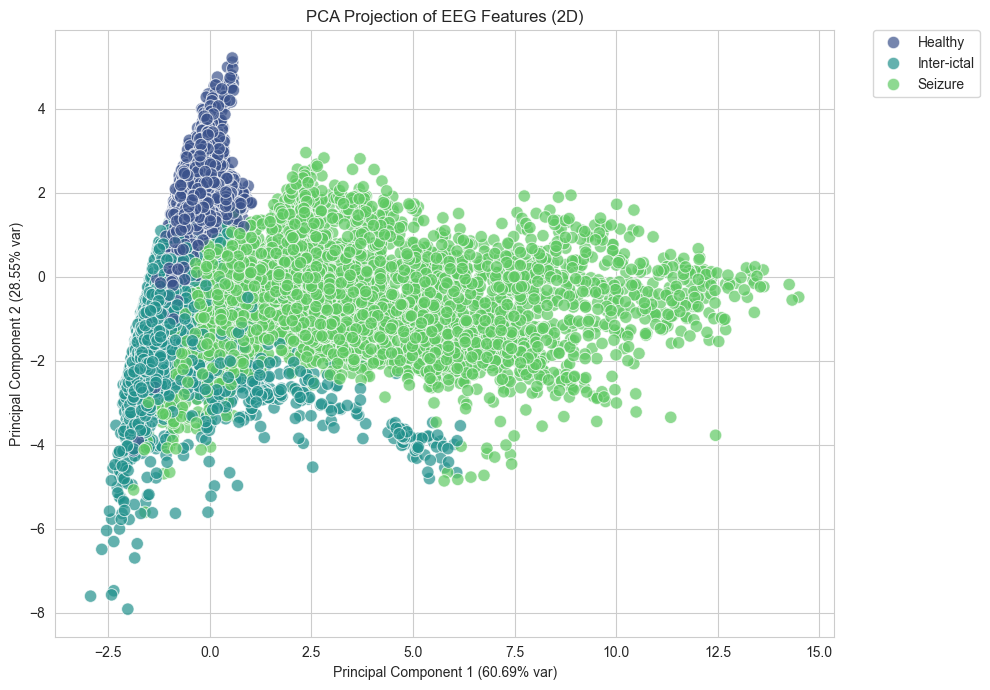

In [5]:
# Standardize features before PCA
X = df[features_present]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = df['Class']

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=pca_df, 
                palette='viridis', alpha=0.7, s=80, 
                hue_order=['Healthy', 'Inter-ictal', 'Seizure'])
plt.title('PCA Projection of EEG Features (2D)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

1.	Зеленият клъстер (Seizure)
o	Точките за пристъп (в светло зелено) са широко разпръснати надясно по оста PC1.
o	Тъй като PC1 обяснява 60% от вариацията, можем да заключим, че тази ос отговаря на Енергията/Амплитудата. Пристъпите имат огромна енергия и затова се отделят толкова ясно от всичко останало.
o	Извод: Моделът ще разпознава пристъпите без никакви проблеми.
2.	Синият и Тюркоазеният клъстер (Healthy vs Inter-ictal)
o	Клас Healthy (тъмно синьо) и Inter-ictal (тюркоазено) са сбутани в лявата част на графиката (ниска енергия).
o	Вижда се частично припокриване между тях, но и известна раздяла по ординатата (PC2).
o	Това потвърждава, че разликата между тях е фина (вероятно честотна, а не амплитудна)
3.	Успеваемост на PCA:
o	Първите два компонента обясняват общо ~89% от цялата информация в данните. Това означава, че 11 признака са силно свързани и могат успешно да бъдат намалени, без да се загуби съществена информация.
Извод: Данните са линейно разделими за клас Seizure, но изискват нелинеен класификатор за финото разделяне на Healthy от Inter-ictal.


## Точка 6: Предложение за включване/изключване (Feature Selection)
**Цел:** Финалният списък с продукти за "пазаруване" за модела.

### Графика: Feature Importance Plot

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_14190/1176832698.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


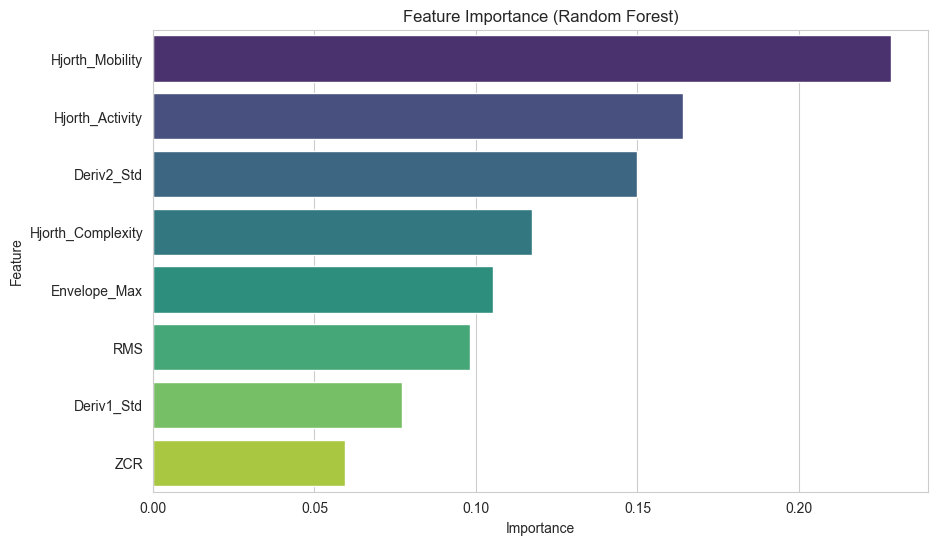

In [6]:
# Train a quick Random Forest to get feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
y = df['Class_Num']
rf.fit(X, y)

importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features_present, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()